# Necessary packages

In [1]:
import numpy as np
import pandas as pd
pd.options.display.float_format='{:.2f}'.format

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from statsmodels.api import qqplot
from scipy.stats import shapiro
from scipy.stats import spearmanr

import warnings
warnings.filterwarnings('ignore')

# %pip install pingouin
# import pingouin

# Project description
In this project I want to investigate which factors impact **prices for the AirBnB apartments** most. I chose Rome for the analysis and found two datasets: prices and other characteristics of the apartments during weekdays and the same features for weekend days.

**Research questions**:
* Does average weekday price differ from average weekend price?
* Is there any difference in price dependencies on various factors during weekdays and weekends?
* Does apartment location influence pricing strategies?
* Do listing rating and Superhost status affect pricing?
* Does the price depend on the apartment purpose (business / non-business)?

**My plan is:**
1. Upload and clean the data, leave only the relevant data.
2. Look at descriptive statistics.
3. Explore general patterns using visualization instruments, formulate hypotheses.
4. Perform hypotheses validation using statistical methods.
5. Make a conclusion.

# Part-1: working with datasets

## Loading data for analysis
Data source: https://www.kaggle.com/datasets/thedevastator/airbnb-prices-in-european-cities

In [2]:
rome_weekdays = pd.read_csv('rome_weekdays.csv')
rome_weekdays['week_time'] = 'Weekdays'
rome_weekends = pd.read_csv('rome_weekends.csv')
rome_weekends['week_time'] = 'Weekends'
df = pd.concat([rome_weekdays, rome_weekends], ignore_index=True)
df = df.drop('Unnamed: 0', axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9027 entries, 0 to 9026
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   realSum                     9027 non-null   float64
 1   room_type                   9027 non-null   object 
 2   room_shared                 9027 non-null   bool   
 3   room_private                9027 non-null   bool   
 4   person_capacity             9027 non-null   float64
 5   host_is_superhost           9027 non-null   bool   
 6   multi                       9027 non-null   int64  
 7   biz                         9027 non-null   int64  
 8   cleanliness_rating          9027 non-null   float64
 9   guest_satisfaction_overall  9027 non-null   float64
 10  bedrooms                    9027 non-null   int64  
 11  dist                        9027 non-null   float64
 12  metro_dist                  9027 non-null   float64
 13  attr_index                  9027 

The dataset contains **9027** observations and no missing values.

**Columns description:**
* realSum — total price of the Airbnb listing;
* room_type — type of room being offered: private, shared, etc.;
* room_shared — whether the room is shared or not;
* room_private — whether the room is private or not;
* person_capacity	— maximum number of people that can stay in the room;
* host_is_superhost — whether the host is a superhost or not;
* multi — whether the listing is for multiple rooms or not;
* biz — whether the listing is for business purposes or not;
* cleanliness_rating — cleanliness rating of the listing;
* guest_satisfaction_overall — overall guest satisfaction rating of the listing;
* bedrooms — number of bedrooms in the listing;
* dist — distance from the city center;
* metro_dist — distance from the nearest metro station;
* attr_index, attr_index_norm, rest_index, rest_index_norm — not described in the source;
* lng, lat — coordinates (the longitude and the latitude) of the listing;
* week_time — for what week time the room is offered: weekdays or weekends.

## Cleaning data
Now let's select the columns I need for further analysis.

I don't choose all the columns due to possible overfitting and problems with multicollinearity.

In [3]:
# Drop room_shared and room_private columns (as variable room_type represents the same information)
df = df.drop(['room_shared', 'room_private'], axis=1)

In [4]:
# Dtypes correction
df['person_capacity'] = df['person_capacity'].astype('int64')
df['biz'] = df['biz'].astype('bool')
df['multi'] = df['multi'].astype('bool')

In [5]:
# Variables person_capacity and bedrooms are interrelated
print(f"Correlation between person capacity and number of bedrooms in the listing: {df['person_capacity'].corr(df['bedrooms']):.2f}\n")

# And data in columns multi and bedrooms is conflicting
display(df[['multi', 'bedrooms']].value_counts(sort=False))

# So I drop bedrooms and multi columns
df = df.drop(['bedrooms', 'multi'], axis=1)

Correlation between person capacity and number of bedrooms in the listing: 0.60



multi  bedrooms
False  0            197
       1           3942
       2           1241
       3            156
       4              7
True   0             82
       1           2721
       2            593
       3             79
       4              8
       5              1
Name: count, dtype: int64

In [6]:
# Variables cleanliness_rating and guest_satisfaction_overall are strongly correlated
print(f"Correlation between cleanliness rating and guest overall satisfaction rating: {df['cleanliness_rating'].corr(df['guest_satisfaction_overall']):.2f}")

# So I continue with guest overall satisfaction rating only
df = df.drop('cleanliness_rating', axis=1)

Correlation between cleanliness rating and guest overall satisfaction rating: 0.71


In [7]:
# Finally, I don't know what variables attr_index, attr_index_norm, rest_index, rest_index_norm stand for,
# because these variables are not described in the source, and don't need data on listings' coordinates for my analysis
df = df.drop(['attr_index', 'attr_index_norm', 'rest_index', 'rest_index_norm', 'lng', 'lat'], axis=1)

In [8]:
# The resulting dataframe
df.head()

,realSum,room_type,person_capacity,host_is_superhost,biz,guest_satisfaction_overall,dist,metro_dist,week_time
0,156.87,Private room,2,True,False,95.00,2.98,1.60,Weekdays
1,172.77,Private room,2,False,False,80.00,0.94,0.65,Weekdays
2,277.75,Entire home/apt,4,False,True,90.00,2.20,0.49,Weekdays
3,444.91,Entire home/apt,6,False,False,92.00,2.70,1.30,Weekdays
4,131.39,Private room,3,False,False,91.00,1.30,0.87,Weekdays


In [9]:
# Rename columns for convenience
df.columns = ['price', 'type', 'capacity', 'superhost', 'biz', 'rating', 'center_dist', 'metro_dist', 'week_time']
df.head()

,price,type,capacity,superhost,biz,rating,center_dist,metro_dist,week_time
0,156.87,Private room,2,True,False,95.00,2.98,1.60,Weekdays
1,172.77,Private room,2,False,False,80.00,0.94,0.65,Weekdays
2,277.75,Entire home/apt,4,False,True,90.00,2.20,0.49,Weekdays
3,444.91,Entire home/apt,6,False,False,92.00,2.70,1.30,Weekdays
4,131.39,Private room,3,False,False,91.00,1.30,0.87,Weekdays


# Part-2: descriptive statistics

## For continuos variables

In [10]:
df[['price', 'rating', 'center_dist', 'metro_dist']].describe()

,price,rating,center_dist,metro_dist
count,9027.00,9027.00,9027.00,9027.00
mean,205.39,93.12,3.03,0.82
std,118.62,7.82,1.64,0.63
min,46.06,20.00,0.04,0.01
25%,138.41,91.00,1.88,0.33
50%,182.59,95.00,2.82,0.62
75%,240.81,98.00,4.03,1.22
max,2418.35,100.00,9.55,4.15


Prices vary from 46.06 to 2418.35, with mean at 205.39.

Guest satisfaction rating varies from 20 to 100, with mean at 93.12.

Distance to the city center varies from 0.04 to 9.55, with mean at 3.03.

Distance to the nearest metro station varies from 0.01 to 4.15, with mean at 0.82.

## For categorical, ordinal and binary variables

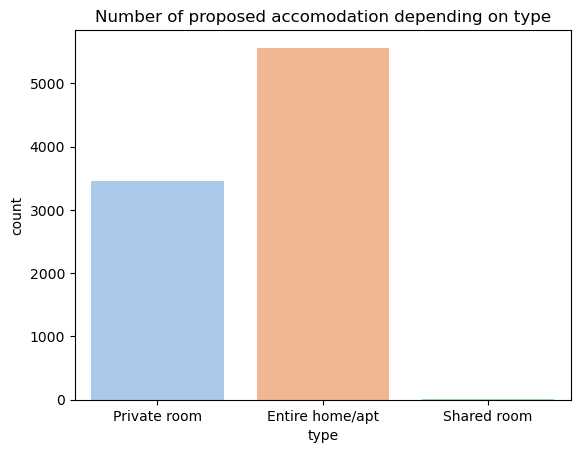

type
Entire home/apt    5561
Private room       3454
Shared room          12
Name: count, dtype: int64

In [11]:
# Room type
sns.countplot(df, x='type', palette='pastel')
plt.title('Number of proposed accomodation depending on type')
plt.show()
display(df['type'].value_counts())

The dataset contains information about 5561 entire appartments offerings, 3454 private rooms and only 12 shared rooms.

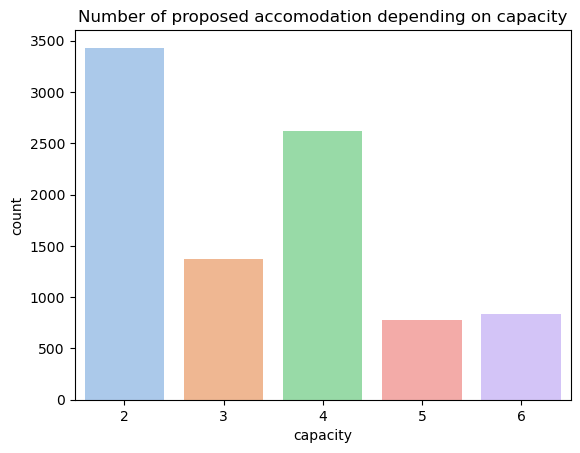

In [12]:
# Person capacity
sns.countplot(df, x='capacity', palette='pastel')
plt.title('Number of proposed accomodation depending on capacity')
plt.show()

Most listing are for 2 or 4 people, about 1500 — for 3 people, and about 2000 for 5-6 taken together.

In [13]:
# Week time
fig = px.pie(df['week_time'].value_counts().reset_index(), values='count', names='week_time', color_discrete_sequence=px.colors.qualitative.Pastel1)
fig.update_layout(autosize=False, height=600, width=600)
fig.show()

The dataset is well-balanced by week time.

In [14]:
# Superhost / not Superhost
fig = px.pie(df['superhost'].value_counts().reset_index(), values='count', names=['Not superhost', 'Superhost'], color_discrete_sequence=px.colors.qualitative.Pastel1)
fig.update_layout(autosize=False, height=600, width=600)
fig.show()

About 33% of listings are offered by hosts with a Superhost status.

In [15]:
# Business purpose / non-business purpose
fig = px.pie(df['biz'].value_counts().reset_index(), values='count', names=['Not for business purposes', 'For business purposes'], color_discrete_sequence=px.colors.qualitative.Pastel1)
fig.update_layout(autosize=False, height=680, width=680)
fig.show()

33.4% of listings are offered for business purposes.

#Part-3: general patterns & hypotheses

### Price, rating and distances pairwise dependencies

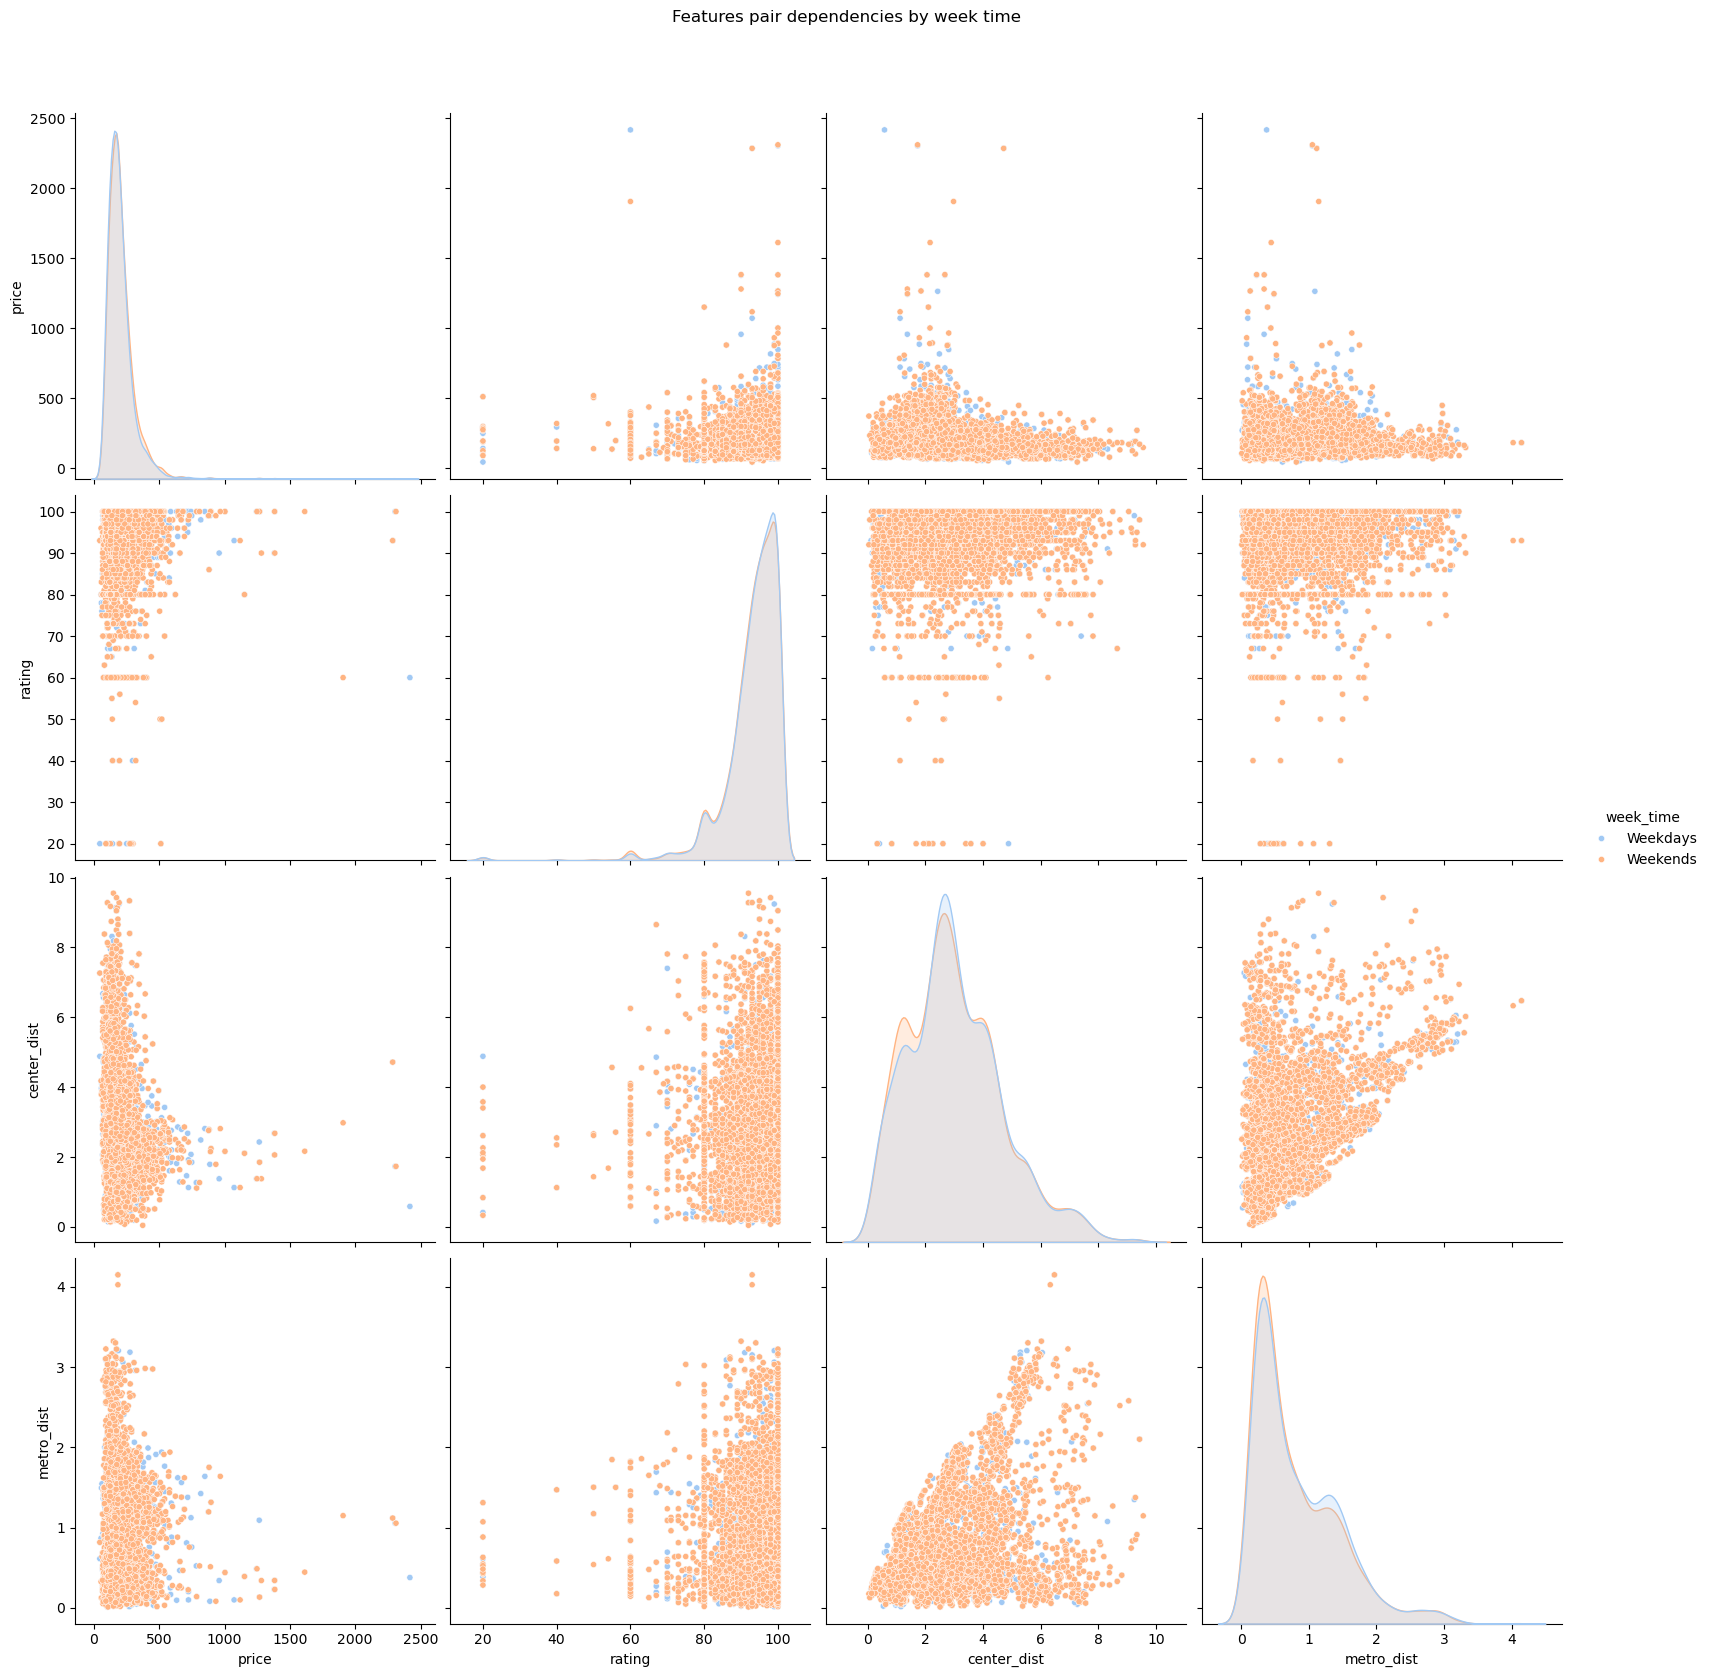

In [16]:
# Let's look at the general patterns now
sns.pairplot(df[['price', 'rating', 'center_dist', 'metro_dist', 'week_time']], hue='week_time', height=4, palette='pastel', plot_kws={'s': 20})
plt.suptitle('Features pair dependencies by week time', y = 1.05)
plt.show()

From the graphs I can observe that:
* all the continuous variables are not normally distributed;
* relationship between price and overall guest satisfaction rating, distances to city center and nearest metro station doesn't really depend on week time;
* prices for listings with low guest satisfaction rating are low, not exceeding 500, while range of prices for listings with high guest satisfaction rating is huge, reaches almost 2500 for some offerings;
* prices for listings with convenient location (near to center / metro station) can be high, while hosts of distant apartments can't afford to set a high price.

### Prices by listing category

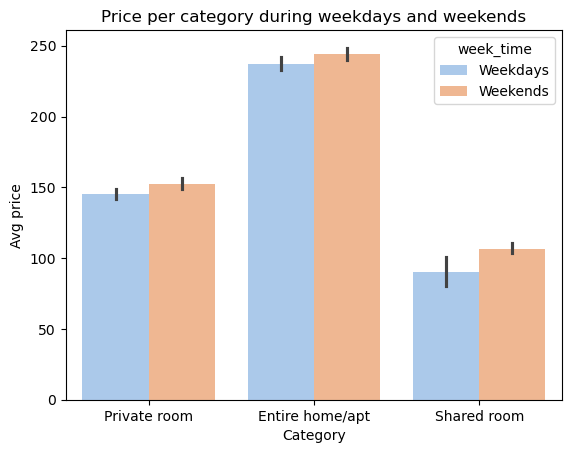

In [17]:
# Let's see some stats by room type
sns.barplot(data=df, x='type', y='price', hue='week_time', palette='pastel')
plt.title('Price per category during weekdays and weekends')
plt.xlabel('Category')
plt.ylabel('Avg price')
plt.show()

From the graph we can see that:
* prices during weekends are on average higher independent of the listing's category;
* entire apartment costs on average higher than a private room, and a private room costs on average higher than a place in shared room, which is quite logical.

### Prices by listing person capacity

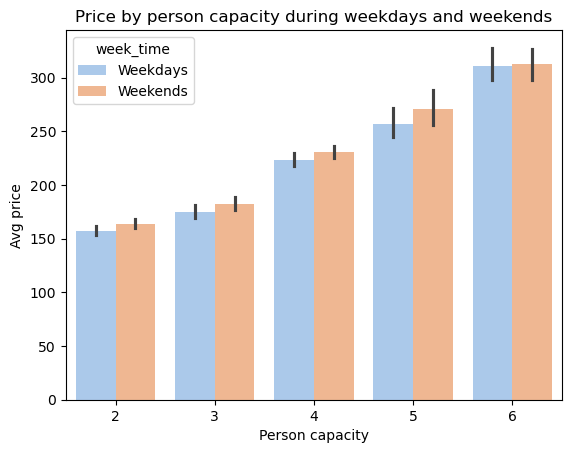

In [18]:
sns.barplot(data=df, x='capacity', y='price', hue='week_time', palette='pastel')
plt.title('Price by person capacity during weekdays and weekends')
plt.xlabel('Person capacity')
plt.ylabel('Avg price')
plt.show()

Again, prices during weekends are on average higher, and prices grow with person capacity.

### Prices dependency on the distance to the city center by apartment purpose (business or not)

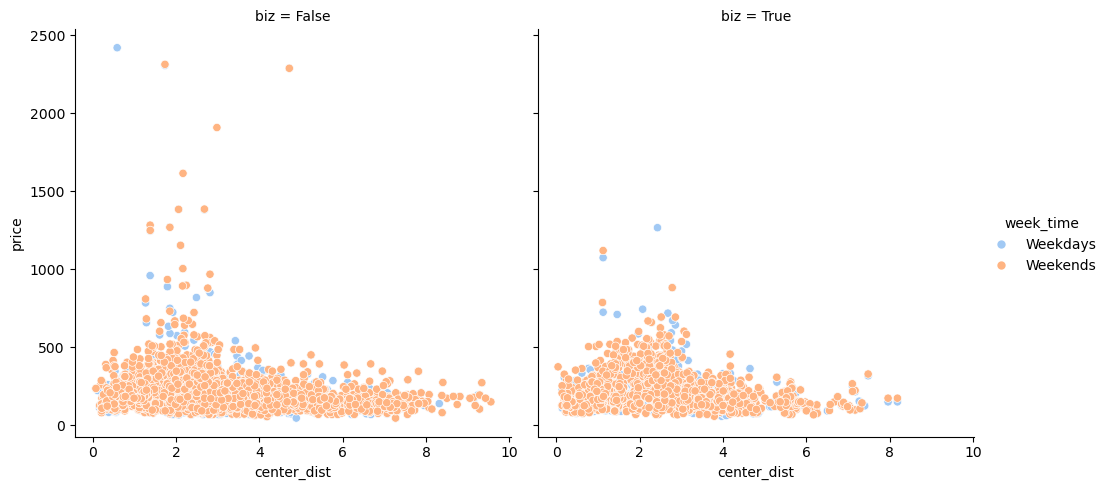

In [19]:
sns.relplot(data=df, x='center_dist', y='price', hue='week_time', col='biz', palette='pastel')
plt.show()

One can suppose that prices for apartments offered for business purposes may be less dependend on the distance to the city center, than prices for touristic-purpose apartments (tourists go sightseeing, walking in the center, etc.). But I don't really see evidence in the graph.

### Is there any difference between prices for apartments serving for business purposes and not?

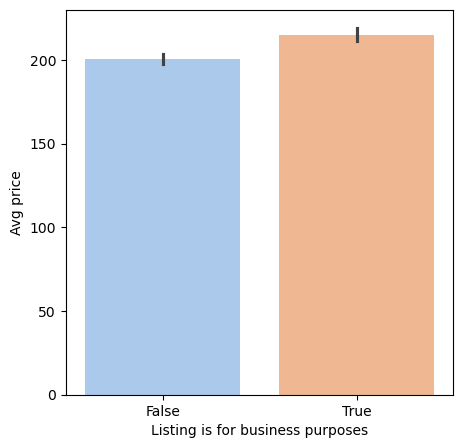

In [20]:
plt.figure(figsize=[5, 5])
sns.barplot(data=df, x='biz', y='price', palette='pastel')
plt.xlabel('Listing is for business purposes')
plt.ylabel('Avg price')
plt.show()

The barplot shows that apartments offered for business purposes are, on average, more expensive than apartments for non-business purposes.

### Does Superhost status add any premium to price for room?

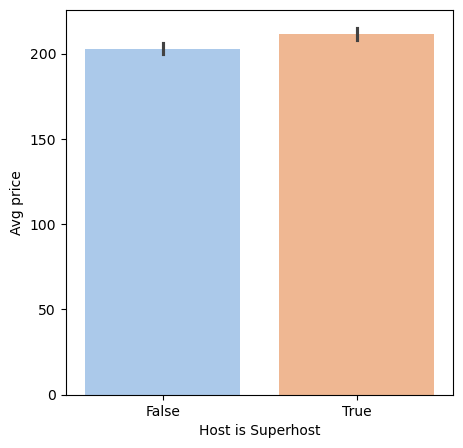

In [21]:
plt.figure(figsize=[5, 5])
sns.barplot(data=df, x='superhost', y='price', palette='pastel')
plt.xlabel('Host is Superhost')
plt.ylabel('Avg price')
plt.show()

According to the graph, apartments offered by Superhosts are, on average, a little more expensive.

### Hypotheses
As a result of conducted visual analysis, I formulate the following hypotheses to be tested using statistical prosedures:
* **H1.** Weekend prices are, on average, more expensive than weekday prices.
* **H2.** Prices for apartments offered for business purposes are, on average, higher.
* **H3.** Prices for apartments offered by hosts with a Superhost status are, on average, higher.
* **H4.** Price is positively correlated with overall guest satisfaction rating.
* **H5.** Price is negatively correlated with distance from the city center.
* **H6.** Price is negatively correlated with distance from the nearest metro station.

# Part-4: hypotheses testing


## Hypothesis №1: weekend prices are more expensive on average than weekday prices

### Checking price distributions for normality

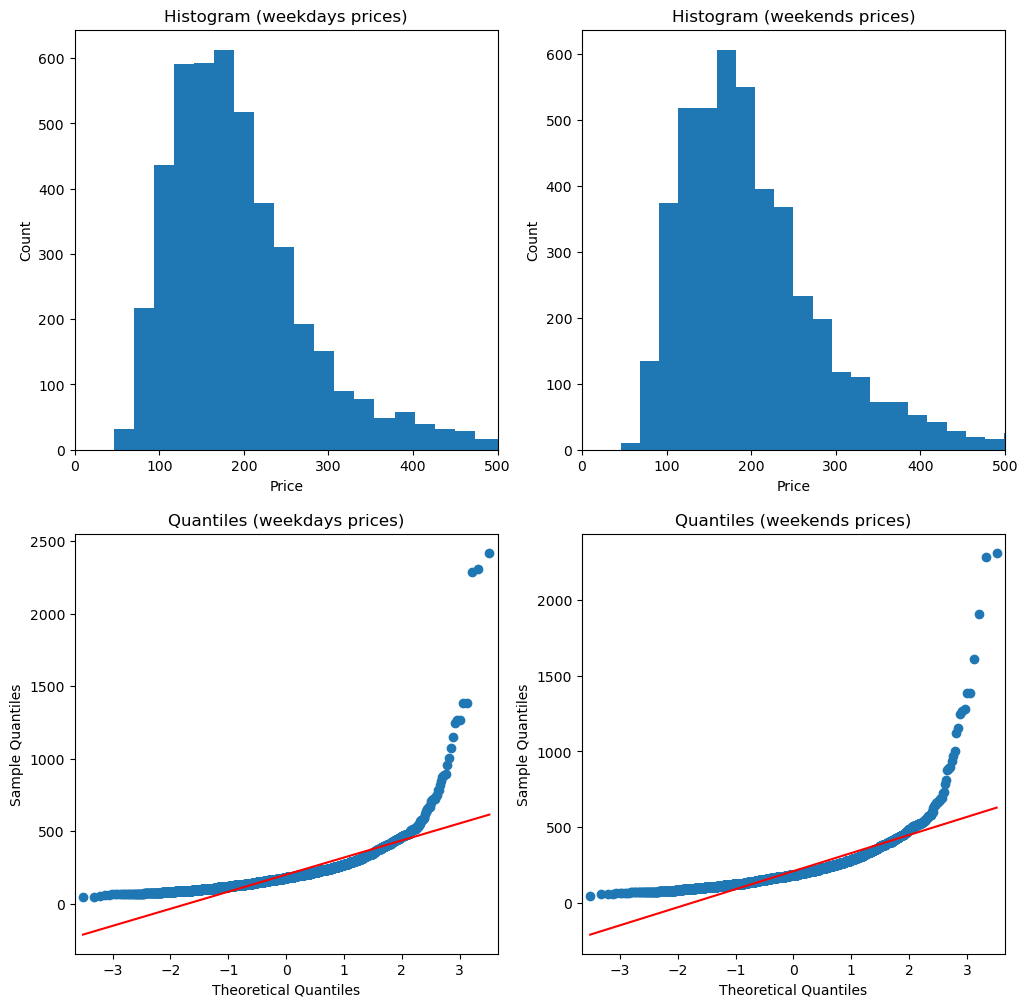

In [22]:
# Checking through visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# Histogram for weekdays
axes[0, 0].hist(df[df['week_time'] == 'Weekdays']['price'], bins=100)
axes[0, 0].set_xlim(0, 500)
axes[0, 0].set_title('Histogram (weekdays prices)')
axes[0, 0].set_xlabel('Price')
axes[0, 0].set_ylabel('Count')

# Histogram for weekends
axes[0, 1].hist(df[df['week_time'] == 'Weekends']['price'], bins=100)
axes[0, 1].set_xlim(0, 500)
axes[0, 1].set_title('Histogram (weekends prices)')
axes[0, 1].set_xlabel('Price')
axes[0, 1].set_ylabel('Count')

# Quantiles for weekdays
qqplot_data_weekdays = qqplot(df[df['week_time'] == 'Weekdays']['price'], line='s', ax=axes[1, 0])
axes[1, 0].set_title('Quantiles (weekdays prices)')

# Quantiles for weekends
qqplot_data_weekends = qqplot(df[df['week_time'] == 'Weekends']['price'], line='s', ax=axes[1, 1])
axes[1, 1].set_title('Quantiles (weekends prices)')

plt.show()

In [23]:
# Now let's check through the test
stat_weekday, p_weekday = shapiro(df[df['week_time'] == 'Weekdays']['price'])
if p_weekday > 0.05:
  print("Weekday prices have normal distribution")
else:
  print("Weekday prices don't really have normal distribution. However, sample size is large enough, so need to use bootstrap.")

stat_weekend, p_weekend = shapiro(df[df['week_time'] == 'Weekends']['price'])
if p_weekend > 0.05:
  print("Weekend prices have normal distribution")
else:
  print("Weekend prices don't really have normal distribution. However, sample size is large enough, so need to use bootstrap.")

Weekday prices don't really have normal distribution. However, sample size is large enough, so need to use bootstrap.
Weekend prices don't really have normal distribution. However, sample size is large enough, so need to use bootstrap.


### Bootsrtapping and checking the difference of means

95% confidence interval: [2.707, 12.291]



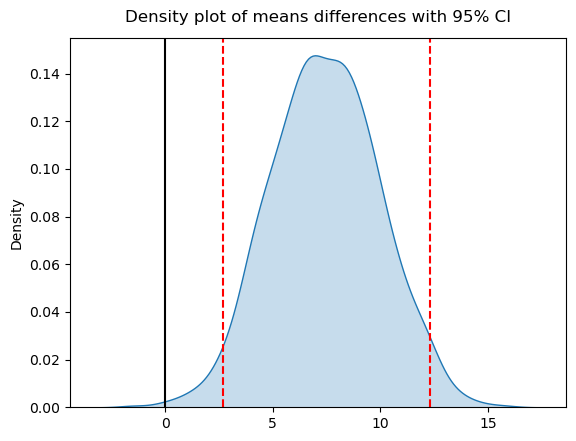

In [24]:
weekday_prices = df[df['week_time'] == 'Weekdays']['price']
weekend_prices = df[df['week_time'] == 'Weekends']['price']

means = []
for i in range(0, 1000):
  samp1 = weekday_prices.sample(frac = 1, replace = True)
  samp2 = weekend_prices.sample(frac = 1, replace = True)
  samp_mean = np.mean(samp2) - np.mean(samp1)
  means.append(samp_mean)

# Now let's conduct a 95% confidence interval
interval = [round(np.quantile(means, 0.025), 3), round(np.quantile(means, 0.975), 3)]
print(f"95% confidence interval: {interval}\n")

# Visualize the results
sns.kdeplot(means, fill = True)
plt.axvline(interval[0], color = 'red', linestyle = '--')
plt.axvline(interval[1], color = 'red', linestyle = '--')
plt.axvline(0, color = 'black', linestyle = '-')
plt.title('Density plot of means differences with 95% CI', y = 1.02)
plt.show()

The confidence interval doesn't include 0 and lies to the right of 0, so the difference between average weekend price and average weekday price is statistically significant, with average weekend price being higher.

## Hypothesis №2: prices for apartments offered for business purposes are, on average, higher


95% confidense interval: [9.639, 19.188]



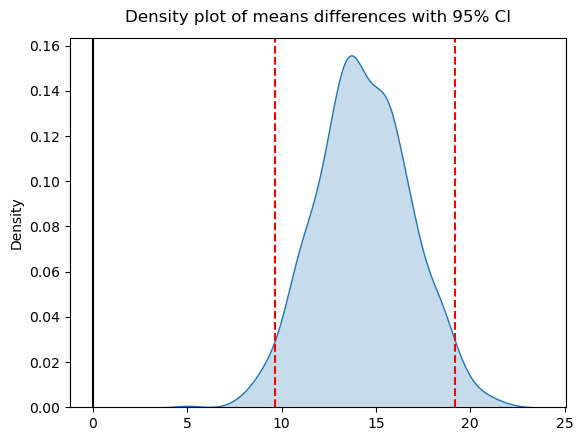

In [25]:
# Check using the same approach, as prices are not normally distributed
business_prices = df[df['biz'] == True]['price']
non_business_prices = df[df['biz'] == False]['price']

means = []
for i in range(0, 1000):
  samp1 = non_business_prices.sample(frac = 1, replace = True)
  samp2 = business_prices.sample(frac = 1, replace = True)
  samp_mean = np.mean(samp2) - np.mean(samp1)
  means.append(samp_mean)

# A 95% confidence interval
interval = [round(np.quantile(means, 0.025), 3), round(np.quantile(means, 0.975), 3)]
print(f"95% confidense interval: {interval}\n")

# Visualize the results
sns.kdeplot(means, fill = True)
plt.axvline(interval[0], color = 'red', linestyle = '--')
plt.axvline(interval[1], color = 'red', linestyle = '--')
plt.axvline(0, color = 'black', linestyle = '-')
plt.title('Density plot of means differences with 95% CI', y = 1.02)
plt.show()

A positive range of the confidence interval suggests that the difference of means is statistically significant, supporting the hypothesis that apartments for business purposes are, on average, more expensive.

## Hypothesis №3: prices for rooms offered by hosts with a Superhost status are, on average, higher

95% confidense interval: [3.731, 13.544]



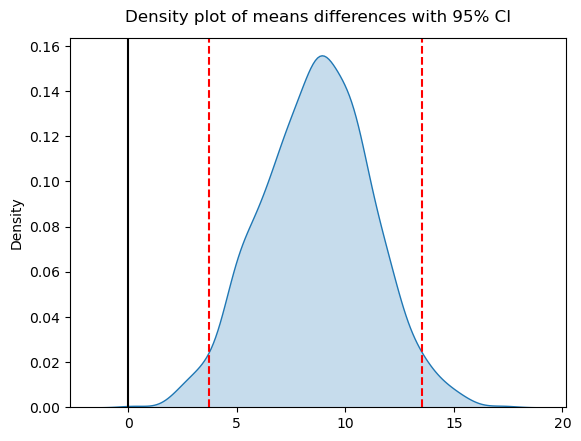

In [26]:
# Check using the same approach, as prices are not normally distributed
super_prices = df[df['superhost'] == True]['price']
not_super_prices = df[df['superhost'] == False]['price']

means = []
for i in range(0, 1000):
  samp1 = not_super_prices.sample(frac = 1, replace = True)
  samp2 = super_prices.sample(frac = 1, replace = True)
  samp_mean = np.mean(samp2) - np.mean(samp1)
  means.append(samp_mean)

# A 95% confidence interval
interval = [round(np.quantile(means, 0.025), 3), round(np.quantile(means, 0.975), 3)]
print(f"95% confidense interval: {interval}\n")

# Visualize the results
sns.kdeplot(means, fill = True)
plt.axvline(interval[0], color = 'red', linestyle = '--')
plt.axvline(interval[1], color = 'red', linestyle = '--')
plt.axvline(0, color = 'black', linestyle = '-')
plt.title('Density plot of means differences with 95% CI', y = 1.02)
plt.show()

The сonfidence interval lies to the right of 0, supporting the hypothesis that having a Superhost status is associated with higher pricing for apartments. This may reflect the premium that customers are willing to pay for the perceived reliability and quality associated with Superhost status.

## Hypothesis №4: price is positively correlated with guest satisfaction rating
Hypotheses about correlation are tested with a non-parametric approach (Spearman rank-order correlation coefficient and associated p-value), because the data isn't normally distributed.

In [27]:
# Test hypothesis of correlation coefficient being equal to 0 against one-sided alternative (>0)
corr, p_val = spearmanr(df['price'], df['rating'], alternative='greater')
print(f'Correlation between price and guest satisfaction rating: {corr:.3f}, p-value: {p_val:.3f}')

Correlation between price and guest satisfaction rating: 0.109, p-value: 0.000


The Spearman rank-order correlation test reveals a weak, but statistically significant positive correlation between price and overall guest satisfaction rating.

## Hypothesis №5: price is negatively correlated with distance from the city center

In [28]:
# Test hypothesis of correlation coefficient being equal to 0 against one-sided alternative (<0)
corr, p_val = spearmanr(df['price'], df['center_dist'], alternative='less')
print(f'Correlation between price and distance to the city center: {corr:.3f}, p-value: {p_val:.3f}')

Correlation between price and distance to the city center: -0.221, p-value: 0.000


The test confirms a statistically significant negative correlation between price and distance to the city center. Rooms closer to the center are generally priced higher, supporting the hypothesis.

## Hypothesis №6: price is negatively correlated with distance from the nearest metro station

In [29]:
# Test hypothesis of correlation coefficient being equal to 0 against one-sided alternative (<0)
corr, p_val = spearmanr(df['price'], df['metro_dist'], alternative='less')
print(f'Correlation between price and distance to the nearest metro station: {corr:.3f}, p-value: {p_val:.3f}')

Correlation between price and distance to the nearest metro station: 0.102, p-value: 1.000


Contrary to expectations, there is no statistically significant evidence that apartments distant from metro stations are generally priced cheaper. The null hypothesis of the test (of no correlation) is not rejected against one-sided alternative (of negative correlation).

# Part-5: Conclusion

## Main points:
- cleaning: dropping irrelevant data, merging & concatenating;

- visualization:
  - matplotlib: histograms;
  - seaborn: pairplots, countplots, relplots, barplots and density plots;
  - qqplot: sample vs theoretical quantiles plots;
  - plotly: pie plots;

- analysis:
  - descriptive analysis;
  - Shapiro test: check the distribution of prices;
  - bootstrapping: create samples and confidence interval according to CLT;
  - Spearman rank correlation test.

## Results (answers to research questions):
- Prices on weekends are, on average, more expensive than on weekdays.
- No difference in dependences: prices and other features have quite the same patterns during weekdays and weekends.
- Apartment location influences pricing strategies. To be specific, the closer apartment is to the city center, the higher price, on average, is set. Surprisingly, there is no strong evidence of similar relationship between price and distance to the nearest metro station.
- Price for apartment is positively related to it's overall guest satisfaction rating, and there exists a price premium for host's Superhost status.
- Apartments serving for business purposes are, on average, more expensive.


